In [143]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import matplotlib.ticker as mtick
import seaborn as sns 
df = pd.read_csv('retail_store_sales.csv')
import warnings 
warnings.filterwarnings('ignore')

In [144]:
df.info()  # Analising data types, non missing values
df.shape   # N° rows and N° of columns

# Problems: Syntactic errors
# Quantity           -> float64  FIX consider int (no fractional units)
# Transaction Date   -> object   FIX -> should be datetime
# Discount Applied   -> object   FIX -> should be boolean

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  object 
 1   Customer ID       12575 non-null  object 
 2   Category          12575 non-null  object 
 3   Item              11362 non-null  object 
 4   Price Per Unit    11966 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    12575 non-null  object 
 8   Location          12575 non-null  object 
 9   Transaction Date  12575 non-null  object 
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(8)
memory usage: 1.1+ MB


(12575, 11)

In [145]:
# Transaction Date ->Parse datetime
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], errors = 'coerce')

# Discount Applied -> boolean
df['Discount Applied'] = df['Discount Applied'].astype('boolean')

# Quantity -> integer (nullable Int64, since it still has missing values)
df['Quantity'] = df['Quantity'].astype('Int64')

In [146]:
df.columns.tolist() # analise the name of the columns

#Problems: blank spaces in the names of the columns, Capital letters


['Transaction ID',
 'Customer ID',
 'Category',
 'Item',
 'Price Per Unit',
 'Quantity',
 'Total Spent',
 'Payment Method',
 'Location',
 'Transaction Date',
 'Discount Applied']

In [147]:
# delete blank spaces, transform cap to lower and replace spaces between words.
df.columns = df.columns.str.strip( ).str.lower().str.replace(' ','_') 

In [148]:
df.isnull().sum() # search for null values


transaction_id         0
customer_id            0
category               0
item                1213
price_per_unit       609
quantity             604
total_spent          604
payment_method         0
location               0
transaction_date       0
discount_applied    4199
dtype: int64

In [149]:
(df.isnull().mean() * 100).round(2) # proportion of missing values

#Problems: 
#Item, Price per unit, Quantity, Total spent, Discount applied

transaction_id       0.00
customer_id          0.00
category             0.00
item                 9.65
price_per_unit       4.84
quantity             4.80
total_spent          4.80
payment_method       0.00
location             0.00
transaction_date     0.00
discount_applied    33.39
dtype: float64

In [150]:
print("Before:")
print(df[['price_per_unit', 'quantity', 'total_spent']].isna().sum())

# Recover total_spent when price and quantity are both known
mask = df['total_spent'].isna() & df['price_per_unit'].notna() & df['quantity'].notna()
df.loc[mask, 'total_spent'] = df['price_per_unit'] * df['quantity']

# Recover quantity when price and total are both known
mask = df['quantity'].isna() & df['price_per_unit'].notna() & df['total_spent'].notna()
df.loc[mask, 'quantity'] = df['total_spent'] / df['price_per_unit']

# Recover price_per_unit when quantity and total are both known
mask = df['price_per_unit'].isna() & df['quantity'].notna() & df['total_spent'].notna()
df.loc[mask, 'price_per_unit'] = df['total_spent'] / df['quantity']

print("After:")
print(df[['price_per_unit', 'quantity', 'total_spent']].isna().sum())

Before:
price_per_unit    609
quantity          604
total_spent       604
dtype: int64
After:
price_per_unit      0
quantity          604
total_spent       604
dtype: int64


In [151]:
# Check that in both columns this NULL values are missing simultaniously, what makes no calculation possible
both_missing = df['quantity'].isna() & df['total_spent'].isna()
print(both_missing.sum())

604


In [152]:
# For each (category, price) combination, count how many distinct items map to it
check = df.groupby(['category', 'price_per_unit'])['item'].nunique()

# If every combination maps to exactly 1 item, price uniquely identifies item within a category
print(check.value_counts())

1    200
Name: item, dtype: int64


In [153]:
# Build a lookup table: (category, price_per_unit) -> item, using only rows where item is known
lookup = df.dropna(subset=['item']).drop_duplicates(subset=['category', 'price_per_unit'])
lookup = lookup.set_index(['category', 'price_per_unit'])['item']

# Rows eligible for recovery: item missing, but category and price_per_unit both known
mask = df['item'].isna() & df['price_per_unit'].notna()

# Map each eligible row's (category, price) to its recovered item
keys = pd.MultiIndex.from_frame(df.loc[mask, ['category', 'price_per_unit']])
df.loc[mask, 'item'] = keys.map(lookup)

In [154]:
(df.isnull().mean() * 100).round(2) # proportion of missing values

transaction_id       0.00
customer_id          0.00
category             0.00
item                 0.00
price_per_unit       0.00
quantity             4.80
total_spent          4.80
payment_method       0.00
location             0.00
transaction_date     0.00
discount_applied    33.39
dtype: float64

In [155]:
# Check duplicates at three levels of strictness

# 1. Exact full-row duplicates: same values across ALL columns
print("Exact full-row duplicates:", df.duplicated().sum())

# 2. Duplicate Transaction IDs: same transaction_id appearing more than once
print("Duplicate Transaction IDs:", df['transaction_id'].duplicated().sum())

# 3. Duplicates ignoring transaction_id: same values across every OTHER column,
#    which would catch disguised duplicates recorded under a different ID
cols_no_id = [c for c in df.columns if c != 'transaction_id']
print("Duplicates ignoring Transaction ID:", df.duplicated(subset=cols_no_id).sum())


Exact full-row duplicates: 0
Duplicate Transaction IDs: 0
Duplicates ignoring Transaction ID: 0


In [156]:
# Semantic value check for 0 or negative values in any of this 3 columns. 
# if they where any negative values or 0 values we may have understand them as a broken transaction or refunds and create 
# another column to approach that

mask = (df['price_per_unit'] <= 0) | (df['quantity'] <= 0) | (df['total_spent'] <= 0)
count = mask.sum()

print("Rows with at least one invalid value:", count)

if count > 0:
    df[mask]

Rows with at least one invalid value: 0


In [157]:
print(df['category'].unique())

['Patisserie' 'Milk Products' 'Butchers' 'Beverages' 'Food' 'Furniture'
 'Electric household essentials' 'Computers and electric accessories']


In [158]:
# Check whether each Item's embedded category code actually matches its Category column value

# Extract the suffix code from the Item column (the part after the last underscore)
df['item_suffix'] = df['item'].str.rsplit('_', n=1).str[-1]

# Build the expected mapping: which suffix code belongs to which Category
category_to_suffix = {
    'Beverages': 'BEV',
    'Butchers': 'BUT',
    'Computers and electric accessories': 'CEA',
    'Electric household essentials': 'EHE',
    'Food': 'FOOD',
    'Furniture': 'FUR',
    'Milk Products': 'MILK',
    'Patisserie': 'PAT'
}

# Map each row's Category to its expected suffix
df['expected_suffix'] = df['category'].map(category_to_suffix)

# Check: rows where Item exists but its suffix doesn't match the expected one for its Category
mismatch = df[df['item'].notna() & (df['item_suffix'] != df['expected_suffix'])]

print("Rows with mismatched Item/Category:", len(mismatch))
if len(mismatch) > 0:
    mismatch[['item', 'category', 'item_suffix', 'expected_suffix']]

Rows with mismatched Item/Category: 0


In [159]:
df = df.drop(columns=['item_suffix', 'expected_suffix'])

In [160]:
# General consistency check: does price_per_unit x quantity always equal total_spent?

sub = df.dropna(subset=['price_per_unit', 'quantity', 'total_spent'])
mismatch = sub[abs(sub['price_per_unit'] * sub['quantity'] - sub['total_spent']) > 0.01]
print("Rows where Total Spent != Price x Quantity:", len(mismatch))

Rows where Total Spent != Price x Quantity: 0


In [161]:
# Compare Total Spent to Price x Quantity specifically for rows where a discount was applied
# Problem: there are no actaul discounts, so there is a semantic problem with the discount applied column

discounted = df[df['discount_applied'] == True]
mismatch = discounted[abs(discounted['price_per_unit'] * discounted['quantity'] - discounted['total_spent']) > 0.01]

print("Discounted rows where Total Spent differs from Price x Quantity:", len(mismatch))


Discounted rows where Total Spent differs from Price x Quantity: 0


In [162]:
# Drop discount_applied: verified earlier that flagged discounts never actually
# reduce total_spent (Total = Price x Quantity holds in 100% of rows regardless
# of this flag), so the column carries no usable information for analysis

df = df.drop(columns=['discount_applied'])

In [163]:
# Outliers detection

# Outlier detection using the Z-score method (threshold = 3 std deviations)

for col in ['price_per_unit', 'quantity', 'total_spent']:
    data = df[col].dropna()  # drop missing values first, they'd break the mean/std calculation             

    mean = np.mean(data)
    std = np.std(data)
    z_scores = (data - mean) / std         # how many std deviations each value is from the mean

    threshold = 3
    outliers = data[abs(z_scores) >= threshold]   # flag values 3+ std devs away (either direction)

    print(f"{col}: {len(outliers)} outliers found")
    if len(outliers) > 0:
        print(outliers.values)
    print()
    

price_per_unit: 0 outliers found

quantity: 0 outliers found

total_spent: 0 outliers found



In [164]:
# Fill missing quantity using the mode quantity for that same item, is an assumption
item_mode = df.groupby('item')['quantity'].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else pd.NA)
df['quantity'] = df['quantity'].fillna(df['item'].map(item_mode))

# Recalculate total_spent using the now-filled quantity
df['total_spent'] = df['total_spent'].fillna(df['price_per_unit'] * df['quantity'])


In [165]:
# ENRICHMENT

# Extract the day of the week from transaction_date (Monday-Sunday)
df['day_of_week'] = df['transaction_date'].dt.day_name()

# is_weekend: True if the transaction happened on Saturday or Sunday
df['is_weekend'] = df['transaction_date'].dt.dayofweek >= 5


# Extract month and year from transaction_date - useful for spotting seasonal patterns
df['month'] = df['transaction_date'].dt.month
df['year'] = df['transaction_date'].dt.year

# Split total_spent into three roughly equal-sized groups based on its distribution
# (not equal-width ranges - each group contains about a third of all transactions)
spend_category = pd.qcut(df['total_spent'], q=3, labels=['Low-value', 'Mid-value', 'High-value'])

# Insert it right after total_spent, instead of at the end of the DataFrame
df.insert(df.columns.get_loc('total_spent') + 1, 'spend_category', spend_category)

df.head()


,transaction_id,customer_id,category,item,price_per_unit,quantity,total_spent,spend_category,payment_method,location,transaction_date,day_of_week,is_weekend,month,year
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10,185.0,High-value,Digital Wallet,Online,2024-04-08,Monday,False,4,2024
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9,261.0,High-value,Digital Wallet,Online,2023-07-23,Sunday,True,7,2023
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2,43.0,Low-value,Credit Card,Online,2022-10-05,Wednesday,False,10,2022
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9,247.5,High-value,Credit Card,Online,2022-05-07,Saturday,True,5,2022
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7,87.5,Mid-value,Digital Wallet,Online,2022-10-02,Sunday,True,10,2022


In [166]:
df.nunique()

transaction_id      12575
customer_id            25
category                8
item                  200
price_per_unit         25
quantity               10
total_spent           227
spend_category          3
payment_method          3
location                2
transaction_date     1114
day_of_week             7
is_weekend              2
month                  12
year                    4
dtype: int64

In [167]:
df_clean = df.copy()

In [ ]:
# DATA VISUALIZATION

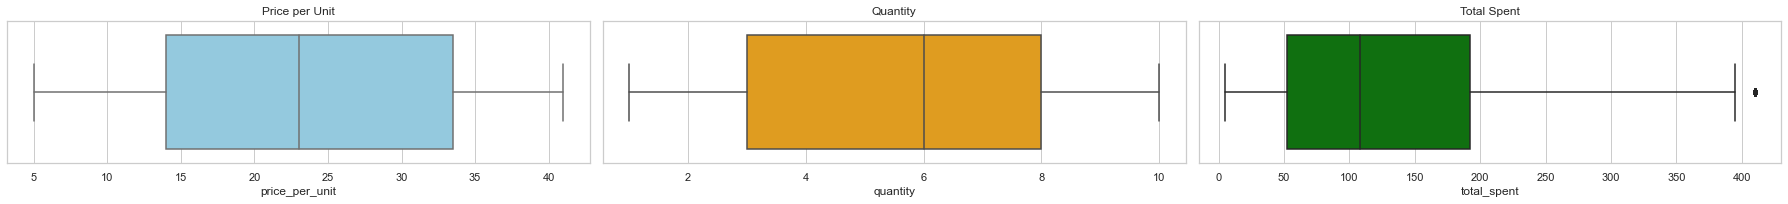

In [183]:

# Boxplots for numeric columns
fig, axes = plt.subplots(1, 3, figsize=(25, 3))

sns.boxplot(x=df_clean['price_per_unit'], ax=axes[0], color='skyblue')
axes[0].set_title('Price per Unit')

sns.boxplot(x=df_clean['quantity'], ax=axes[1], color='orange')
axes[1].set_title('Quantity')

sns.boxplot(x=df_clean['total_spent'], ax=axes[2], color='green')
axes[2].set_title('Total Spent')

plt.tight_layout()
plt.show()

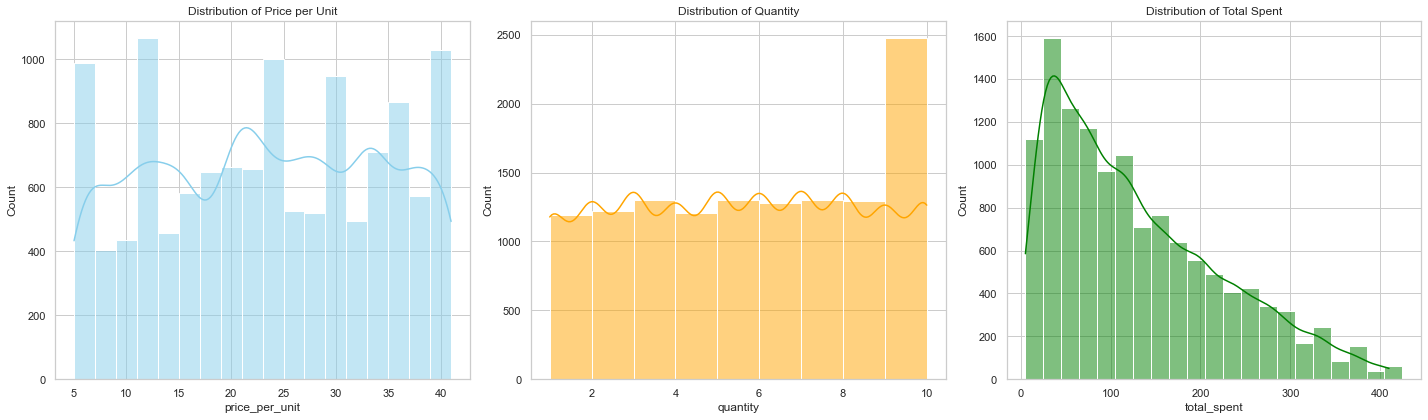

In [177]:
# Histograms with KDE for the same columns
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.histplot(df_clean['price_per_unit'], kde=True, ax=axes[0], binwidth=2, color='skyblue')
axes[0].set_title('Distribution of Price per Unit')

sns.histplot(df_clean['quantity'], kde=True, ax=axes[1], binwidth=1, color='orange')
axes[1].set_title('Distribution of Quantity')

sns.histplot(df_clean['total_spent'], kde=True, ax=axes[2], binwidth=20, color='green')
axes[2].set_title('Distribution of Total Spent')


plt.tight_layout()
plt.show()

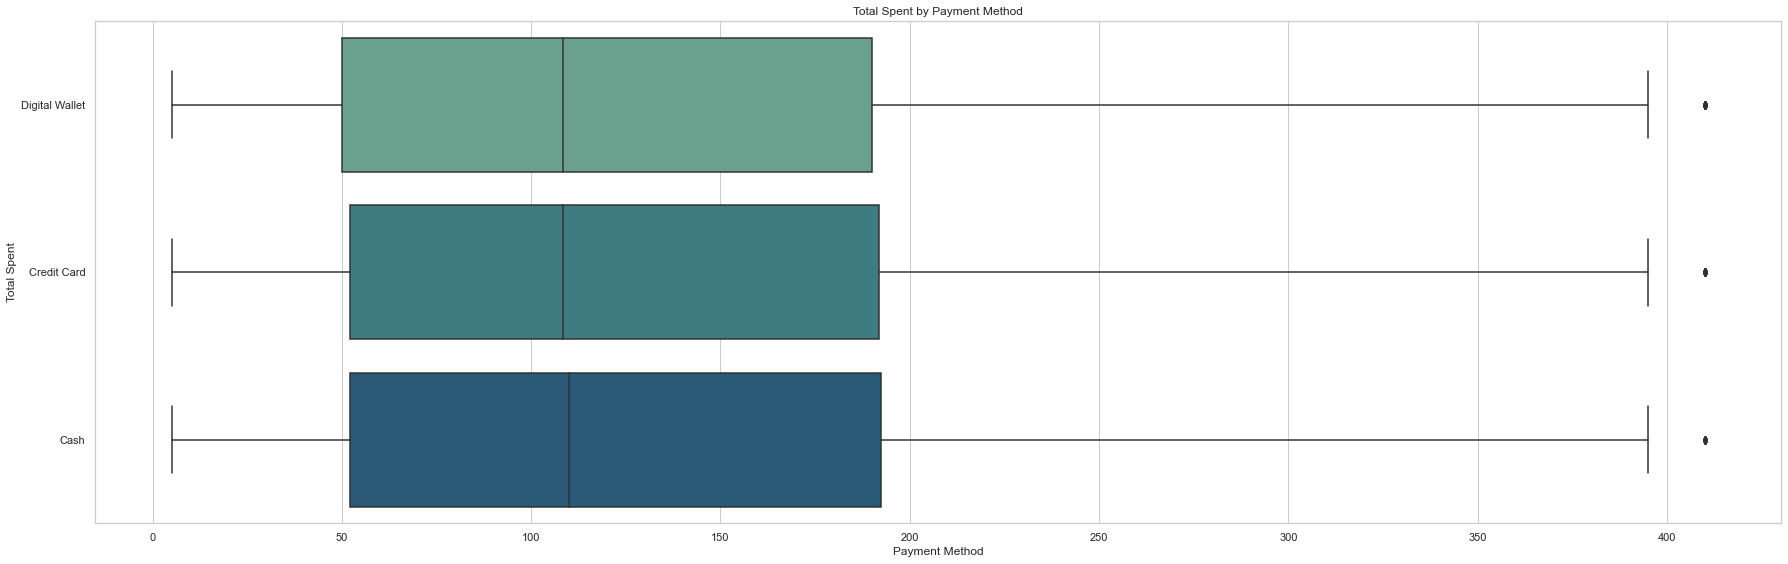

In [227]:
plt.figure(figsize=(25, 8))
sns.boxplot(data=df_clean, y='payment_method', x='total_spent', palette='crest')
plt.title('Total Spent by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Total Spent')
plt.tight_layout()
plt.show()

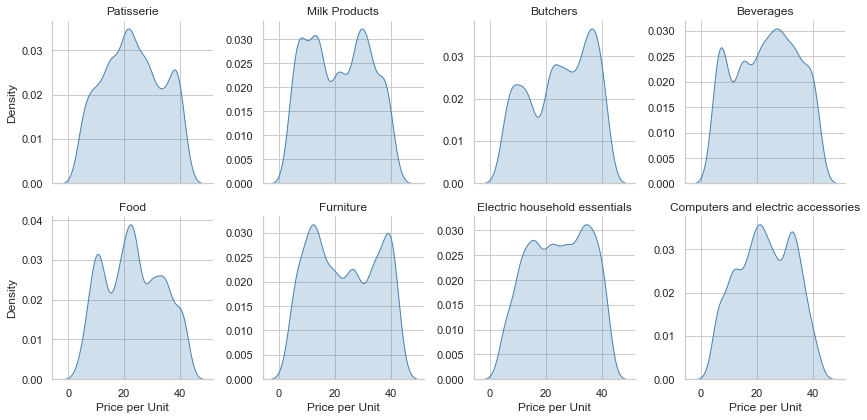

In [188]:
# Faceted KDE: one small subplot per category, easier to compare than overlapping curves
g = sns.FacetGrid(df_clean, col="category", col_wrap=4, height=3, sharex=True, sharey=False)
g.map(sns.kdeplot, "price_per_unit", fill=True, color="steelblue")
g.set_titles("{col_name}")  # use category name as each subplot's title
g.set_axis_labels("Price per Unit", "Density")
plt.tight_layout()
plt.show()

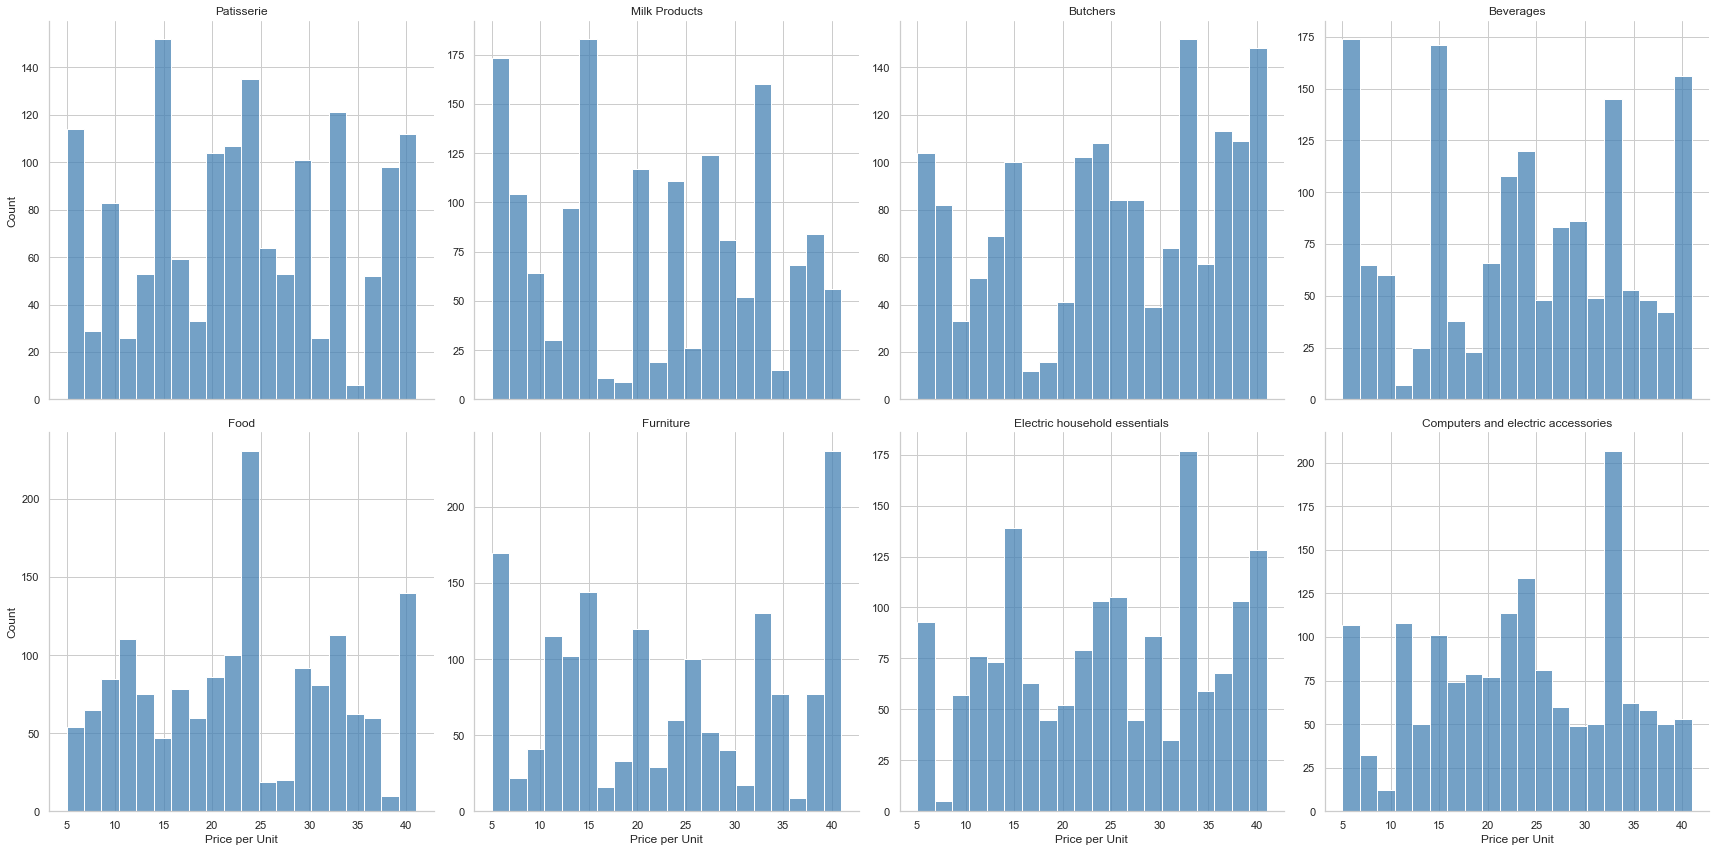

In [195]:
g = sns.FacetGrid(df_clean, col="category", col_wrap=4, height=6, sharex=True, sharey=False)
g.map(sns.histplot, "price_per_unit", bins=20, color="steelblue")
g.set_titles("{col_name}")
g.set_axis_labels("Price per Unit", "Count")
plt.tight_layout()
plt.show()

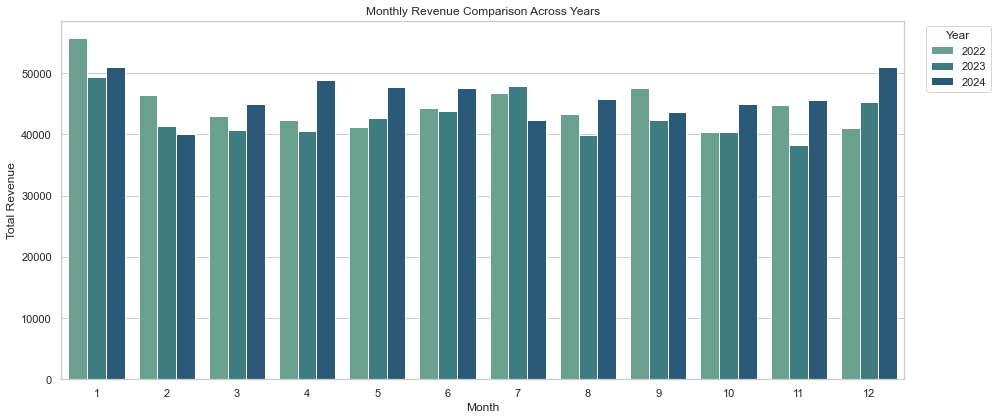

In [205]:
revenue_by_month = df_clean[df_clean['year'] != 2025].groupby(['year', 'month'])['total_spent'].sum().reset_index()
plt.figure(figsize=(14, 6))
sns.barplot(
    data=revenue_by_month,
    x='month',
    y='total_spent',
    hue='year',
    palette='crest'
)
plt.title('Monthly Revenue Comparison Across Years')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.legend(title='Year', bbox_to_anchor=(1.02, 1), loc='upper left')  # moves legend outside the plot area, to the right
plt.tight_layout()
plt.show()

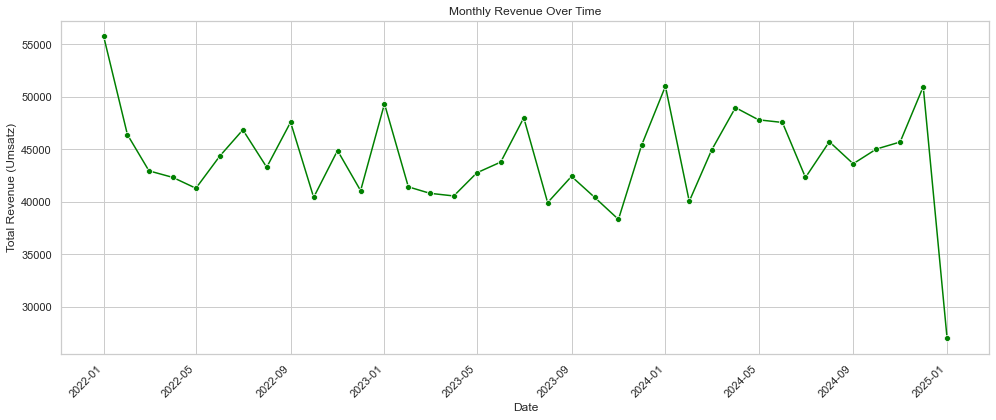

In [201]:
# Total revenue (Umsatz) per year-month combination, across the full dataset timeline
revenue_by_month = df_clean.groupby(['year', 'month'])['total_spent'].sum().reset_index()

# Create a proper date column so months are ordered chronologically on the x-axis
revenue_by_month['date'] = pd.to_datetime(
    revenue_by_month['year'].astype(str) + '-' + revenue_by_month['month'].astype(str) + '-01'
)

plt.figure(figsize=(14, 6))
sns.lineplot(data=revenue_by_month, x='date', y='total_spent', marker='o', color='green')
plt.title('Monthly Revenue Over Time')
plt.xlabel('Date')
plt.ylabel('Total Revenue (Umsatz)')
plt.xticks(rotation=45, ha='right')  # rotate date labels so they don't overlap
plt.tight_layout()
plt.show()

In [213]:
# Total revenue and average transaction value: weekend vs weekday
weekend_summary = df_clean.groupby('is_weekend')['total_spent'].agg(['sum', 'mean', 'count']).reset_index()
weekend_summary['is_weekend'] = weekend_summary['is_weekend'].map({True: 'Weekend', False: 'Weekday'})
print(weekend_summary)

  is_weekend        sum        mean  count
0    Weekday  1159169.0  129.126546   8977
1    Weekend   471791.0  131.125903   3598


In [217]:
# Total revenue for weekday vs weekend
totals = df_clean.groupby('is_weekend')['total_spent'].sum()

# Divide by the actual number of distinct weekday/weekend dates present in the dataset
days_count = df_clean.groupby('is_weekend')['transaction_date'].nunique()

daily_avg = (totals / days_count).reset_index()
daily_avg.columns = ['is_weekend', 'avg_revenue_per_day']
daily_avg['is_weekend'] = daily_avg['is_weekend'].map({True: 'Weekend', False: 'Weekday'})

print(daily_avg)

  is_weekend  avg_revenue_per_day
0    Weekday          1458.074214
1    Weekend          1478.968652


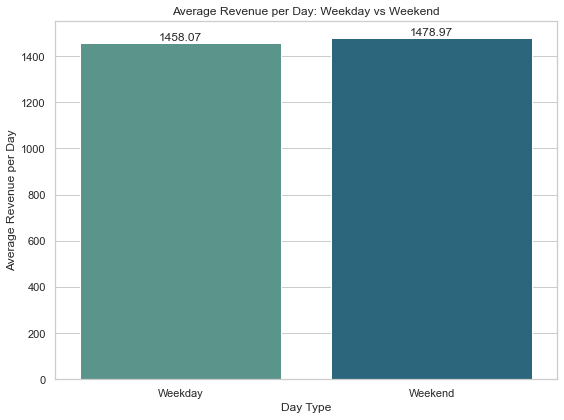

In [221]:
plt.figure(figsize=(8, 6))
ax = sns.barplot(data=daily_avg, x='is_weekend', y='avg_revenue_per_day', palette='crest')
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')
plt.title('Average Revenue per Day: Weekday vs Weekend')
plt.xlabel('Day Type')
plt.ylabel('Average Revenue per Day')
plt.tight_layout()
plt.show()

In [219]:
df_clean.head()

,transaction_id,customer_id,category,item,price_per_unit,quantity,total_spent,spend_category,payment_method,location,transaction_date,day_of_week,is_weekend,month,year
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10,185.0,High-value,Digital Wallet,Online,2024-04-08,Monday,False,4,2024
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9,261.0,High-value,Digital Wallet,Online,2023-07-23,Sunday,True,7,2023
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2,43.0,Low-value,Credit Card,Online,2022-10-05,Wednesday,False,10,2022
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9,247.5,High-value,Credit Card,Online,2022-05-07,Saturday,True,5,2022
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7,87.5,Mid-value,Digital Wallet,Online,2022-10-02,Sunday,True,10,2022


In [228]:
# Cross-tabulation: counts of each category/payment_method combination
crosstab = pd.crosstab(df_clean['category'], df_clean['payment_method'])
print(crosstab)

payment_method                      Cash  Credit Card  Digital Wallet
category                                                             
Beverages                            580          479             508
Butchers                             520          553             495
Computers and electric accessories   547          519             492
Electric household essentials        539          487             565
Food                                 560          506             522
Furniture                            527          530             534
Milk Products                        527          541             516
Patisserie                           510          506             512


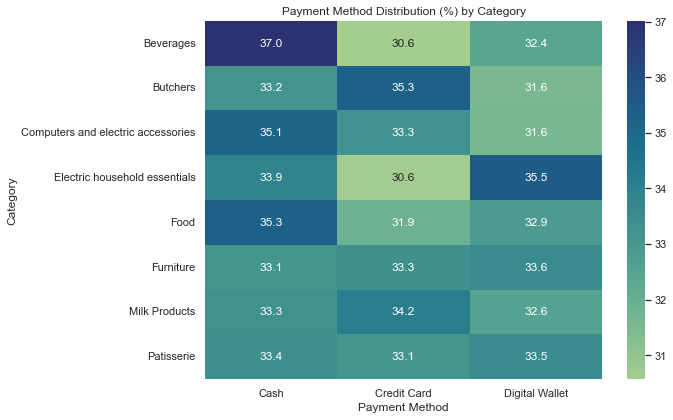

In [229]:
# Normalize by row: within each category, what % used each payment method?
crosstab_pct = pd.crosstab(df_clean['category'], df_clean['payment_method'], normalize='index') * 100

plt.figure(figsize=(10, 6))
sns.heatmap(crosstab_pct, annot=True, fmt='.1f', cmap='crest')
plt.title('Payment Method Distribution (%) by Category')
plt.xlabel('Payment Method')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

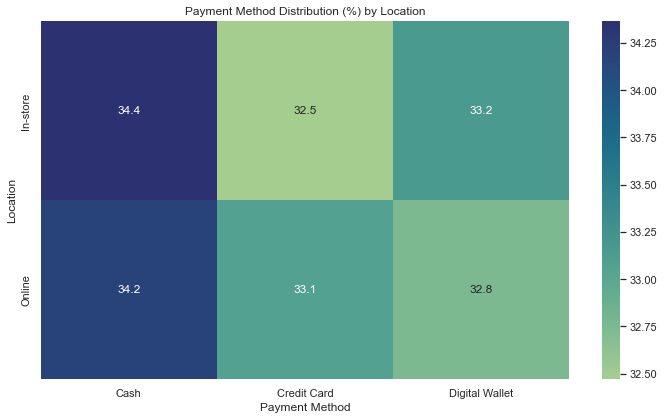

In [231]:
# Cross-tabulation: % of each payment method within Online vs In-store
crosstab_pct = pd.crosstab(df_clean['location'], df_clean['payment_method'], normalize='index') * 100

plt.figure(figsize=(10, 6))
sns.heatmap(crosstab_pct, annot=True, fmt='.1f', cmap='crest')
plt.title('Payment Method Distribution (%) by Location')
plt.xlabel('Payment Method')
plt.ylabel('Location')
plt.tight_layout()
plt.show()

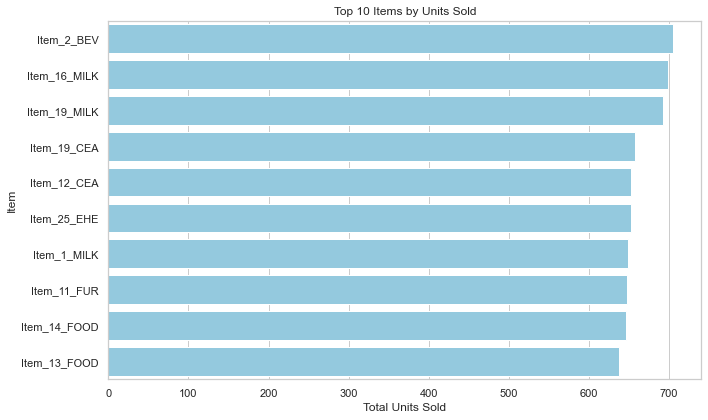

In [232]:
# Top 10 items by total units sold
top_items_units = df_clean.groupby('item')['quantity'].sum().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=top_items_units, x='quantity', y='item', color='skyblue')
plt.title('Top 10 Items by Units Sold')
plt.xlabel('Total Units Sold')
plt.ylabel('Item')
plt.tight_layout()
plt.show()

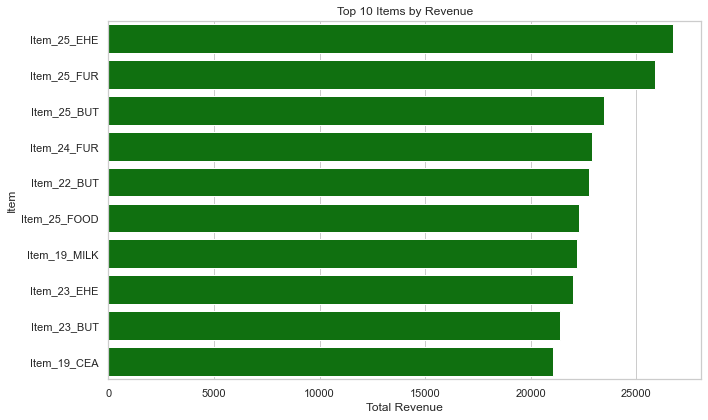

In [234]:
# Top 10 items by total revenue generated
top_items_revenue = df_clean.groupby('item')['total_spent'].sum().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=top_items_revenue, x='total_spent', y='item', color='green')
plt.title('Top 10 Items by Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Item')
plt.tight_layout()
plt.show()

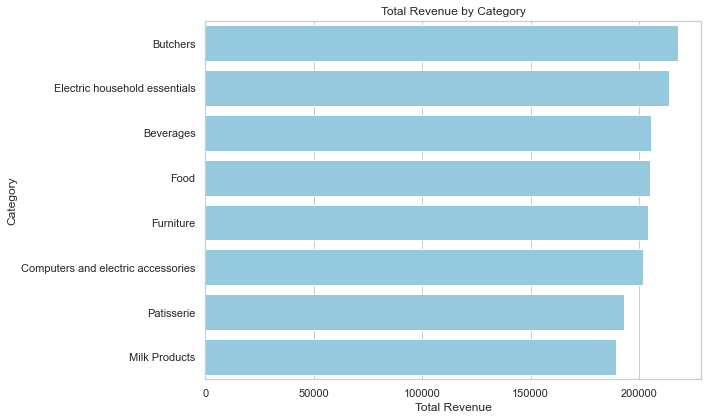

In [238]:
# Total revenue by category, sorted descending
revenue_by_category = df_clean.groupby('category')['total_spent'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=revenue_by_category, x='total_spent', y='category', color='skyblue')
plt.title('Total Revenue by Category')
plt.xlabel('Total Revenue')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

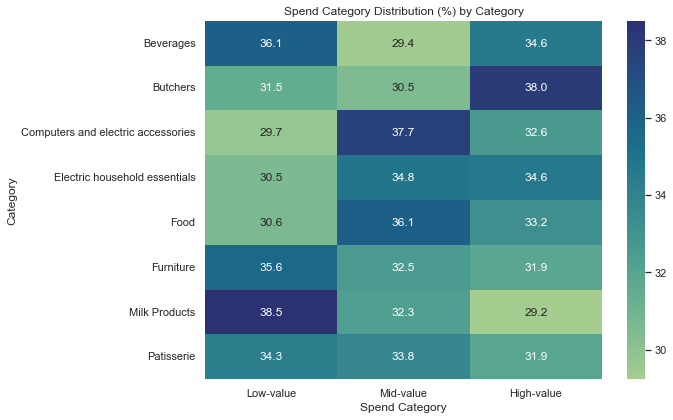

In [236]:
# Crosstab: % of transactions in each spend_category, per category
crosstab_pct = pd.crosstab(df_clean['category'], df_clean['spend_category'], normalize='index') * 100

plt.figure(figsize=(10, 6))
sns.heatmap(crosstab_pct, annot=True, fmt='.1f', cmap='crest')
plt.title('Spend Category Distribution (%) by Category')
plt.xlabel('Spend Category')
plt.ylabel('Category')
plt.tight_layout()
plt.show()